In [1]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/maximillianmahlke/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maximillianmahlke/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [20]:
# 1. Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
import seaborn as sns
import nltk
from IPython.display import display, HTML
from collections import Counter

In [4]:
# Load and display first few rows
df = pd.read_csv('../enriched_dataset.csv')
display(df.head())

,book_collection,csv_file,Title,Subject,Description,content,rating,unique_id,LibrariansSummary,PositiveCharacters,NegativeCharacters,error
0,chinese-fairybook,laotsze-story.csv,Laotsze and the Servant,Fantasy and Imagination,"Laotsze, a magical being, teaches the secret o...",Laotsze is really older than heaven and earth ...,3,ffdc5f15-8b48-4393-8742-3b408b9e493e,The Tale of Laotsze and the Magic Talisman\n\n...,"['Laotsze', 'Guardian of the Pass']",['Rascally Servant'],NaN
1,chinese-fairybook,how-the-river-gods-wedding-was-broken-off-stor...,Si-Men Bau and the River-God's Bride,Life Lessons,Governor Si-Men Bau ends an unfair tradition b...,At the time of the seven empires there lived a...,4,22a76a59-eb94-47a0-b2e2-f4689f71ff95,The Tale of Si-Men Bau and the River-God\n\nIn...,['Si-Men Bau'],"['Sorcerers', 'Witches']",NaN
2,chinese-fairybook,how-the-five-ancients-became-men-story.csv,The Five Ancients and the Creation of the World,Fantasy and Imagination,"In this mythical tale, five elemental spirits ...",Before the earth was separated from the heaven...,5,19da4739-d20d-4246-8d06-2791778078c4,The Birth of Earth and the Ancients\n\nJourney...,"['Yellow Ancient', 'Red Lord', 'Dark Lord', 'W...",['Baneful Gods'],NaN
3,chinese-fairybook,old-dschang-story.csv,Old Dschang's Magic,Fantasy and Imagination,"Old Dschang, a humble gardener, marries a nobl...",Once upon a time there was a man who went by t...,3,94af12ec-7738-4bce-a64c-34b5cdf41652,Old Dschang's Magical Journey\n\nJoin Old Dsch...,"['Old Dschang', ""Sir We's Daughter"", ""Sir We's...",['None'],NaN
4,chinese-fairybook,how-molo-stole-the-lovely-rose-red-story.csv,Molo the Sword Hero,Adventure,"Molo, a magical sword hero, helps young Tsui r...",At the time when the Tang dynasty reigned over...,5,74749aaf-d2fa-4c48-9c3d-cfc1989b0200,The Sword Hero's Secret\n\nSet in the captivat...,"['Molo', 'Tsui', 'Rose-Red']",['The Prince'],NaN


In [5]:
# 2. Basic Dataset Overview
print(f"Total Books: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.info()  # Shows data types and null counts


Total Books: 239
Columns: ['book_collection', 'csv_file', 'Title', 'Subject', 'Description', 'content', 'rating', 'unique_id', 'LibrariansSummary', 'PositiveCharacters', 'NegativeCharacters', 'error']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   book_collection     239 non-null    object
 1   csv_file            239 non-null    object
 2   Title               239 non-null    object
 3   Subject             239 non-null    object
 4   Description         239 non-null    object
 5   content             239 non-null    object
 6   rating              239 non-null    int64 
 7   unique_id           239 non-null    object
 8   LibrariansSummary   238 non-null    object
 9   PositiveCharacters  238 non-null    object
 10  NegativeCharacters  238 non-null    object
 11  error               1 non-null      object
dtypes: int64(1), obje

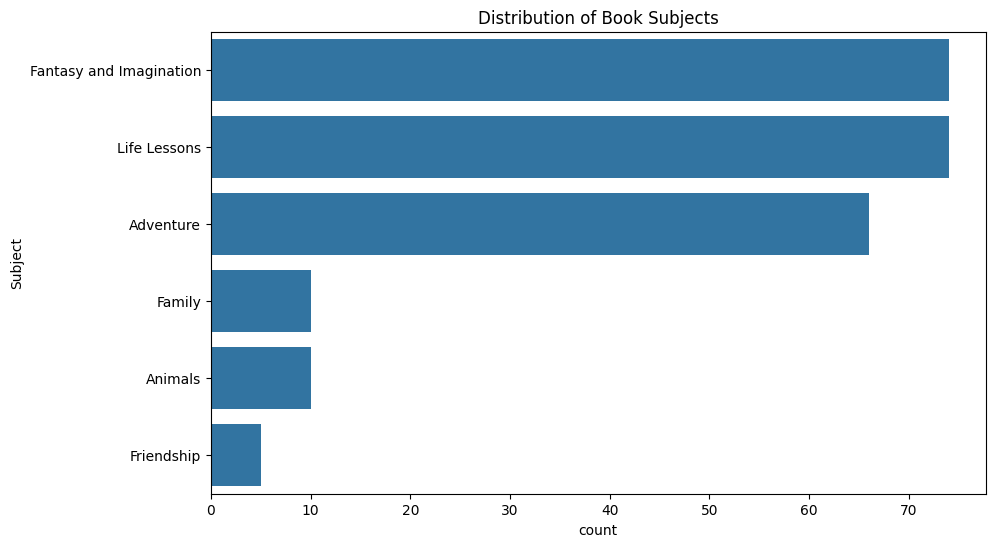

In [6]:
# 3. Subject Analysis
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Subject')
plt.title('Distribution of Book Subjects')
plt.show()

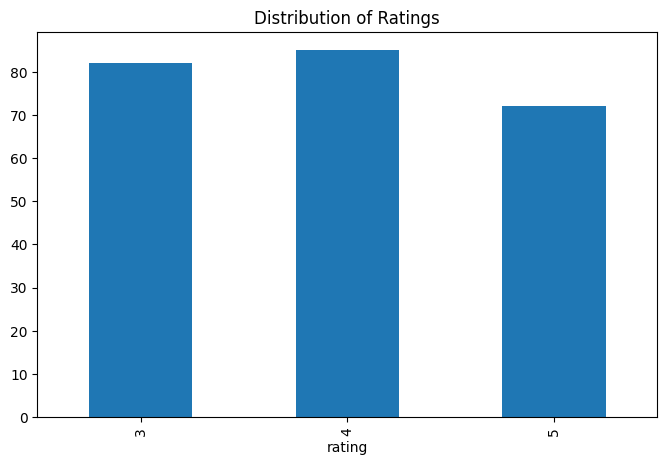

In [7]:
# 4. Rating Analysis
plt.figure(figsize=(8, 5))
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Ratings')
plt.show()

# Let's See What Some EDA reveals over our API response Columns

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk



# Load dataset
df = pd.read_csv('../enriched_dataset.csv')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/maximillianmahlke/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [43]:
# Simple tokenization functions
def simple_tokenize(text):
    if not isinstance(text, str):
        return [], []
    # Remove common punctuation that might affect sentence splitting
    text = text.replace('!', '.').replace('?', '.')
    sentences = [s.strip() for s in text.split('.') if s.strip()]
    words = [w.lower() for w in text.split() if any(c.isalnum() for c in w)]
    return sentences, words

In [44]:
def analyze_text_complexity():
    """
    Analyzes text complexity using word and sentence metrics:
    - Word count: Total words in text
    - Sentence count: Number of sentences (split by periods)
    - Average words per sentence: Complexity measure
    - Vocabulary diversity: Ratio of unique words to total words
    """
    def get_text_metrics(text):
        if not isinstance(text, str):
            return {
                'word_count': 0, 
                'sentence_count': 0, 
                'avg_words_per_sentence': 0, 
                'unique_word_ratio': 0
            }
        
        sentences, words = simple_tokenize(text)
        
        return {
            'word_count': len(words),
            'sentence_count': len(sentences),
            'avg_words_per_sentence': len(words) / len(sentences) if sentences else 0,
            'unique_word_ratio': len(set(words)) / len(words) if words else 0
        }
    
    # Calculate metrics for both columns
    librarian_metrics = pd.DataFrame([get_text_metrics(text) for text in df['LibrariansSummary']])
    description_metrics = pd.DataFrame([get_text_metrics(text) for text in df['Description']])
    
    # Create visualization grid
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Text Complexity Analysis', fontsize=16)
    
    # Word Count Distribution
    sns.kdeplot(data=librarian_metrics['word_count'], ax=axes[0,0], label='LibrariansSummary')
    sns.kdeplot(data=description_metrics['word_count'], ax=axes[0,0], label='Description')
    axes[0,0].set_title('Word Count Distribution')
    axes[0,0].set_xlabel('Number of Words')
    
    # Sentence Count
    sns.boxplot(data=[librarian_metrics['sentence_count'], description_metrics['sentence_count']], 
                ax=axes[0,1])
    axes[0,1].set_xticklabels(['LibrariansSummary', 'Description'])
    axes[0,1].set_title('Sentence Count Distribution')
    
    # Words per Sentence
    sns.violinplot(data=[librarian_metrics['avg_words_per_sentence'], 
                        description_metrics['avg_words_per_sentence']], ax=axes[1,0])
    axes[1,0].set_xticklabels(['LibrariansSummary', 'Description'])
    axes[1,0].set_title('Words per Sentence Distribution')
    
    # Vocabulary Diversity
    sns.scatterplot(data=librarian_metrics, x='word_count', y='unique_word_ratio', 
                   ax=axes[1,1], alpha=0.5, label='LibrariansSummary')
    sns.scatterplot(data=description_metrics, x='word_count', y='unique_word_ratio', 
                   ax=axes[1,1], alpha=0.5, label='Description')
    axes[1,1].set_title('Vocabulary Diversity vs Text Length')
    
    plt.tight_layout()
    return librarian_metrics.mean(), description_metrics.mean()

In [45]:

# 2. Enhanced Subject Distribution Analysis
def analyze_subject_distribution():
    """
    Analyzes the distribution of subjects and their relationships with other metrics:
    - Subject frequency
    - Average ratings per subject
    - Character count distribution by subject
    - Text complexity by subject
    """
    # Create figure with multiple plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Subject Analysis', fontsize=16)
    
    # Subject Distribution
    subject_counts = df['Subject'].value_counts()
    entropy = -(subject_counts/len(df) * np.log2(subject_counts/len(df))).sum()
    sns.barplot(x=subject_counts.values, y=subject_counts.index, ax=axes[0,0])
    axes[0,0].set_title(f'Subject Distribution\nEntropy: {entropy:.2f}')
    
    # Average Rating by Subject
    avg_ratings = df.groupby('Subject')['rating'].mean().sort_values()
    sns.barplot(x=avg_ratings.values, y=avg_ratings.index, ax=axes[0,1])
    axes[0,1].set_title('Average Rating by Subject')
    
    # Text Length by Subject (BoxPlot)
    sns.boxplot(x='Subject', y=df['LibrariansSummary'].str.len(), data=df, ax=axes[1,0])
    axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)
    axes[1,0].set_title('Summary Length by Subject')
    
    # Character Count by Subject
    char_counts = df.apply(lambda x: len(eval(x['PositiveCharacters'])) + 
                                   len(eval(x['NegativeCharacters'])) 
                                   if isinstance(x['PositiveCharacters'], str) else 0, axis=1)
    df['total_chars'] = char_counts
    sns.violinplot(x='Subject', y='total_chars', data=df, ax=axes[1,1])
    axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45)
    axes[1,1].set_title('Character Count Distribution by Subject')
    
    plt.tight_layout()
    return {'entropy': entropy, 'avg_ratings': avg_ratings}

In [46]:

# 3. Enhanced Character List Analysis
def analyze_character_lists():
    """
    Analyzes character distributions and relationships:
    - Positive vs Negative character ratios
    - Character count distributions
    - Character presence across subjects
    - Books with different character combinations
    """
    def get_char_counts(row):
        pos = row['PositiveCharacters']
        neg = row['NegativeCharacters']
        return {
            'positive_count': len(eval(pos)) if isinstance(pos, str) else 0,
            'negative_count': len(eval(neg)) if isinstance(neg, str) else 0
        }
    
    char_counts = pd.DataFrame([get_char_counts(row) for _, row in df.iterrows()])
    char_counts['total'] = char_counts['positive_count'] + char_counts['negative_count']
    
    # Create visualization grid
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Character Analysis', fontsize=16)
    
    # Positive vs Negative Distribution
    sns.scatterplot(data=char_counts, x='positive_count', y='negative_count', 
                   alpha=0.5, ax=axes[0,0])
    axes[0,0].set_title('Positive vs Negative Characters')
    
    # Total Character Distribution
    sns.histplot(data=char_counts, x='total', ax=axes[0,1])
    axes[0,1].set_title('Total Characters per Book')
    
    # Character Counts by Subject
    df['total_chars'] = char_counts['total']
    sns.boxplot(data=df, x='Subject', y='total_chars', ax=axes[1,0])
    axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)
    axes[1,0].set_title('Character Count by Subject')
    
    # Ratio of Positive to Total Characters
    char_counts['pos_ratio'] = char_counts['positive_count'] / char_counts['total'].where(char_counts['total'] > 0)
    sns.histplot(data=char_counts, x='pos_ratio', ax=axes[1,1])
    axes[1,1].set_title('Ratio of Positive to Total Characters')
    
    plt.tight_layout()
    
    # Calculate statistics
    stats = {
        'avg_positive': char_counts['positive_count'].mean(),
        'avg_negative': char_counts['negative_count'].mean(),
        'books_with_characters': (char_counts['total'] > 0).mean() * 100,
        'avg_pos_ratio': char_counts['pos_ratio'].mean(),
        'most_common_total': char_counts['total'].mode().iloc[0]
    }
    
    return stats, char_counts

In [47]:

# 4. Enhanced Content Consistency Check
def check_content_consistency():
    """
    Analyzes data consistency and quality:
    - Missing data patterns
    - Value distributions
    - Cross-column relationships
    - Validity metrics
    """
    # Create visualization grid
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Content Consistency Analysis', fontsize=16)
    
    # Missing Data Heatmap
    sns.heatmap(df.isnull(), cbar=True, ax=axes[0,0])
    axes[0,0].set_title('Missing Data Pattern')
    
    # Text Length Correlations
    length_data = pd.DataFrame({
        'Summary_Length': df['LibrariansSummary'].str.len(),
        'Description_Length': df['Description'].str.len(),
        'Subject': df['Subject']
    })
    sns.scatterplot(data=length_data, x='Summary_Length', y='Description_Length', 
                   hue='Subject', ax=axes[0,1], alpha=0.6)
    axes[0,1].set_title('Summary vs Description Length')
    
    # Rating Distribution by Subject
    sns.boxplot(data=df, x='Subject', y='rating', ax=axes[1,0])
    axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)
    axes[1,0].set_title('Rating Distribution by Subject')
    
    # Text Length Distribution
    sns.kdeplot(data=length_data['Summary_Length'], ax=axes[1,1], label='Summary')
    sns.kdeplot(data=length_data['Description_Length'], ax=axes[1,1], label='Description')
    axes[1,1].set_title('Text Length Distributions')
    
    plt.tight_layout()
    
    # Calculate metrics
    metrics = {
        'complete_entries': (df.notna().all(axis=1).mean() * 100),
        'unique_subjects': df['Subject'].nunique(),
        'valid_summaries': (df['LibrariansSummary'].str.len() > 50).mean() * 100,
        'valid_descriptions': (df['Description'].str.len() > 20).mean() * 100,
        'rating_std': df['rating'].std(),
        'avg_rating': df['rating'].mean()
    }
    
    return metrics, length_data


In [52]:
def analyze_content_lengths():
    """
    Analyzes the length of the actual book content:
    - Distribution of book lengths
    - Average book length
    - Book length by subject
    - Correlation with ratings
    """
    # Calculate content lengths
    df['content_length'] = df['content'].str.len()
    df['content_word_count'] = df['content'].apply(lambda x: len(str(x).split()))
    
    # Create visualization grid
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Book Content Analysis', fontsize=16)
    
    # Character Length Distribution
    sns.histplot(data=df, x='content_length', ax=axes[0,0], bins=30)
    axes[0,0].set_title('Distribution of Book Lengths (Characters)')
    axes[0,0].set_xlabel('Number of Characters')
    
    # Word Count Distribution
    sns.histplot(data=df, x='content_word_count', ax=axes[0,1], bins=30)
    axes[0,1].set_title('Distribution of Book Lengths (Words)')
    axes[0,1].set_xlabel('Number of Words')
    
    # Length by Subject
    sns.boxplot(data=df, x='Subject', y='content_word_count', ax=axes[1,0])
    axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)
    axes[1,0].set_title('Book Length by Subject')
    
    # Length vs Rating
    sns.scatterplot(data=df, x='content_word_count', y='rating', ax=axes[1,1])
    axes[1,1].set_title('Book Length vs Rating')
    
    plt.tight_layout()
    
    # Calculate statistics
    stats = {
        'avg_char_length': df['content_length'].mean(),
        'avg_word_count': df['content_word_count'].mean(),
        'min_length': df['content_word_count'].min(),
        'max_length': df['content_word_count'].max(),
        'median_length': df['content_word_count'].median(),
        'length_std': df['content_word_count'].std()
    }
    
    return stats

In [51]:
def evaluate_ai_columns():
    """
    Comprehensive evaluation of AI-generated content and book characteristics
    """
    print("\n1. Text Complexity Analysis")
    print("-" * 50)
    librarian_metrics, description_metrics = analyze_text_complexity()
    print("\nLibrarian Summary Metrics:")
    for metric, value in librarian_metrics.items():
        print(f"{metric}: {value:.2f}")
    print("\nDescription Metrics:")
    for metric, value in description_metrics.items():
        print(f"{metric}: {value:.2f}")
    
    print("\n2. Subject Distribution Analysis")
    print("-" * 50)
    subject_analysis = analyze_subject_distribution()
    print(f"Subject Entropy (balance): {subject_analysis['entropy']:.2f}")
    print("\nAverage Ratings by Subject:")
    print(subject_analysis['avg_ratings'])
    
    print("\n3. Character Analysis")
    print("-" * 50)
    char_stats, char_data = analyze_character_lists()
    for metric, value in char_stats.items():
        if isinstance(value, float):
            print(f"{metric}: {value:.2f}")
        else:
            print(f"{metric}: {value}")
    
    print("\n4. Content Consistency")
    print("-" * 50)
    consistency_metrics, length_data = check_content_consistency()
    for metric, value in consistency_metrics.items():
        print(f"{metric}: {value:.2f}")
        
    print("\n5. Book Content Analysis")
    print("-" * 50)
    content_stats = analyze_content_lengths()
    print("\nBook Length Statistics:")
    for metric, value in content_stats.items():
        print(f"{metric}: {value:,.2f}")

    plt.show()
    return {
        'text_metrics': {'librarian': librarian_metrics, 'description': description_metrics},
        'subject_analysis': subject_analysis,
        'character_stats': char_stats,
        'consistency_metrics': consistency_metrics,
        'content_stats': content_stats
    }

## Run Evaluation


1. Text Complexity Analysis
--------------------------------------------------

Librarian Summary Metrics:
word_count: 109.05
sentence_count: 4.04
avg_words_per_sentence: 27.03
unique_word_ratio: 0.75

Description Metrics:
word_count: 29.13
sentence_count: 1.77
avg_words_per_sentence: 18.50
unique_word_ratio: 0.89

2. Subject Distribution Analysis
--------------------------------------------------
Subject Entropy (balance): 2.06

Average Ratings by Subject:
Subject
Family                     3.600000
Fantasy and Imagination    3.851351
Life Lessons               3.918919
Animals                    4.100000
Adventure                  4.136364
Friendship                 4.200000
Name: rating, dtype: float64

3. Character Analysis
--------------------------------------------------
avg_positive: 3.19
avg_negative: 1.69
books_with_characters: 99.58
avg_pos_ratio: 0.67
most_common_total: 4

4. Content Consistency
--------------------------------------------------


/var/folders/wk/00k6hfhj7bdd3lcgqt3s7y000000gn/T/ipykernel_56255/821196274.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['LibrariansSummary', 'Description'])
/var/folders/wk/00k6hfhj7bdd3lcgqt3s7y000000gn/T/ipykernel_56255/821196274.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['LibrariansSummary', 'Description'])
/var/folders/wk/00k6hfhj7bdd3lcgqt3s7y000000gn/T/ipykernel_56255/2762073448.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45)
/var/folders/wk/00k6hfhj7bdd3lcgqt3s7y000000gn/T/ipykernel_56255/2762073448.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

complete_entries: 0.00
unique_subjects: 6.00
valid_summaries: 99.58
valid_descriptions: 100.00
rating_std: 0.80
avg_rating: 3.96

5. Book Content Analysis
--------------------------------------------------

Book Length Statistics:
avg_char_length: 11,360.44
avg_word_count: 2,160.30
min_length: 221.00
max_length: 7,495.00
median_length: 1,948.00
length_std: 1,370.78


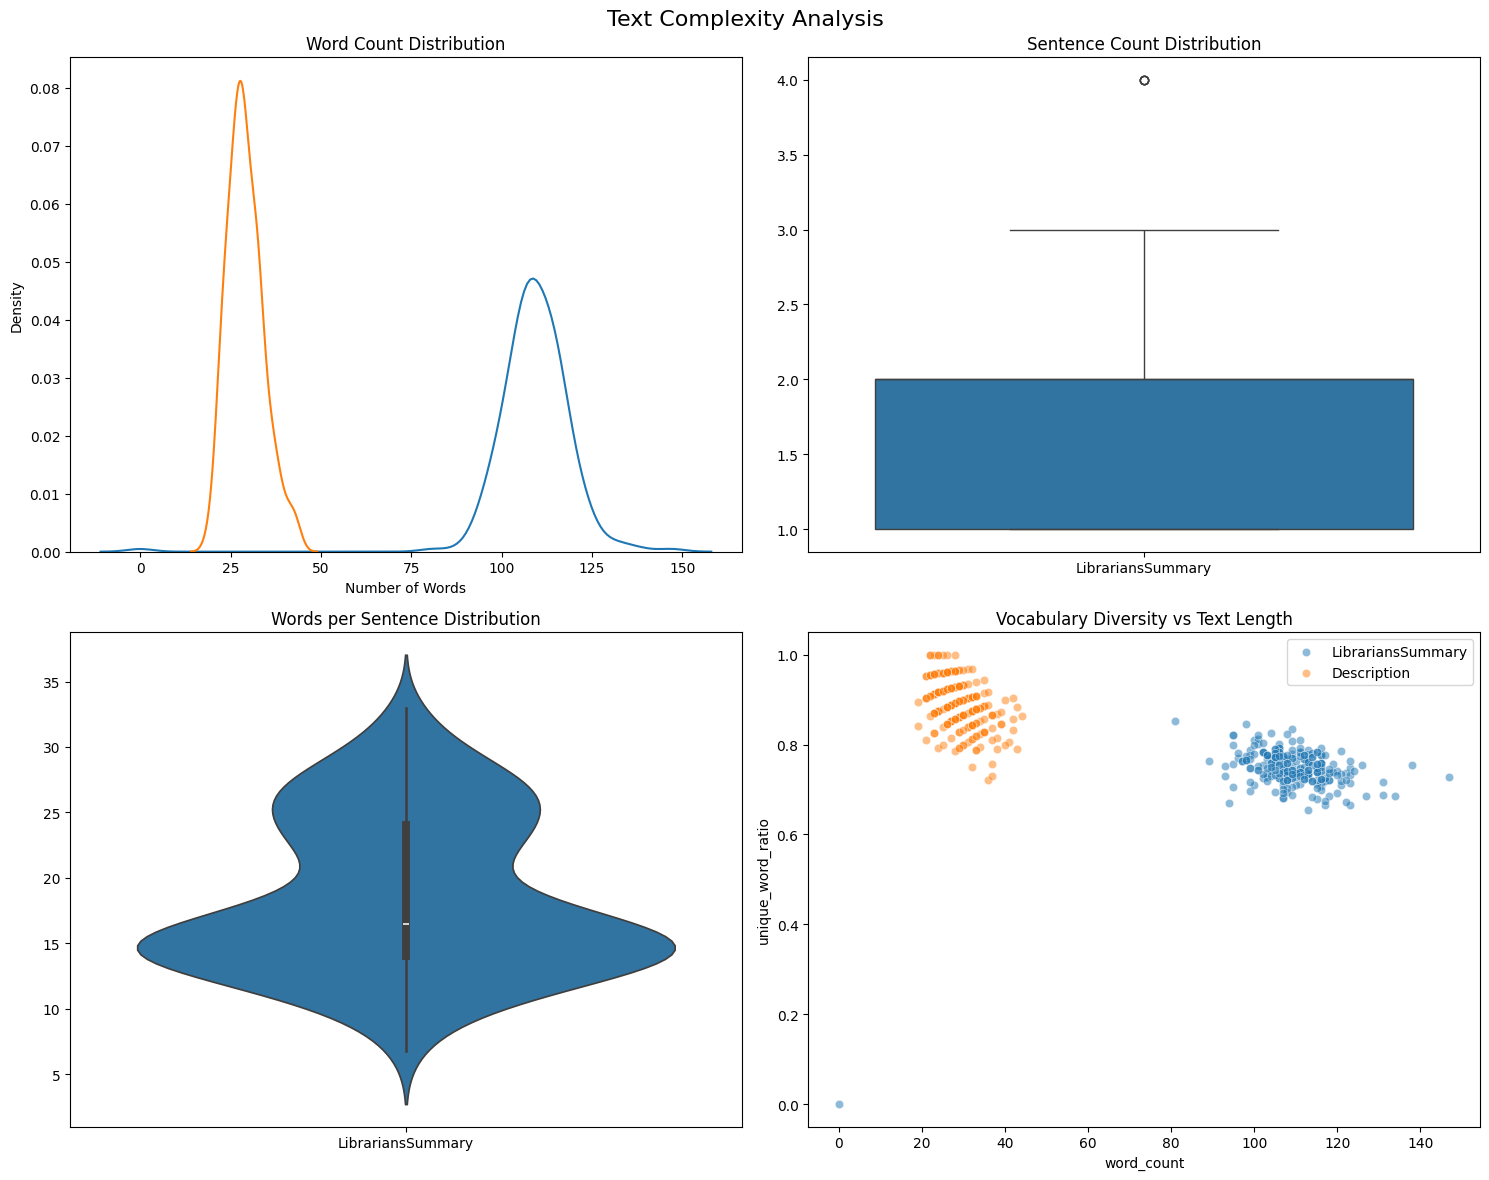

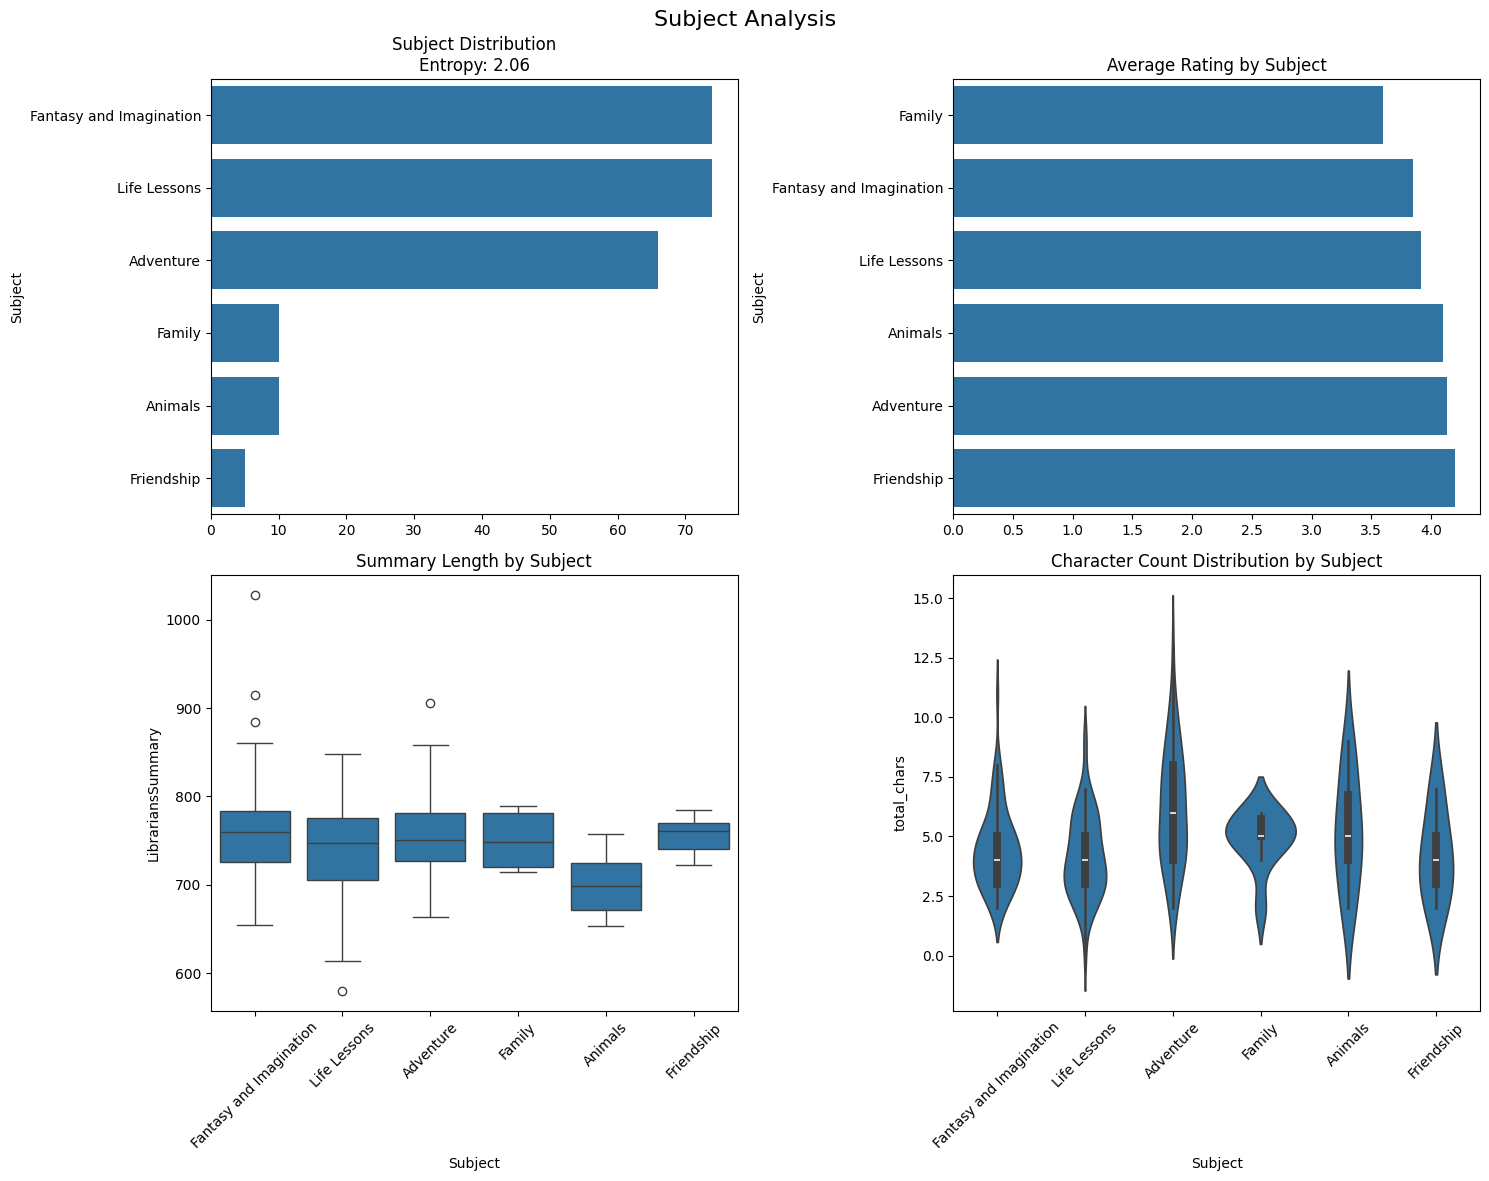

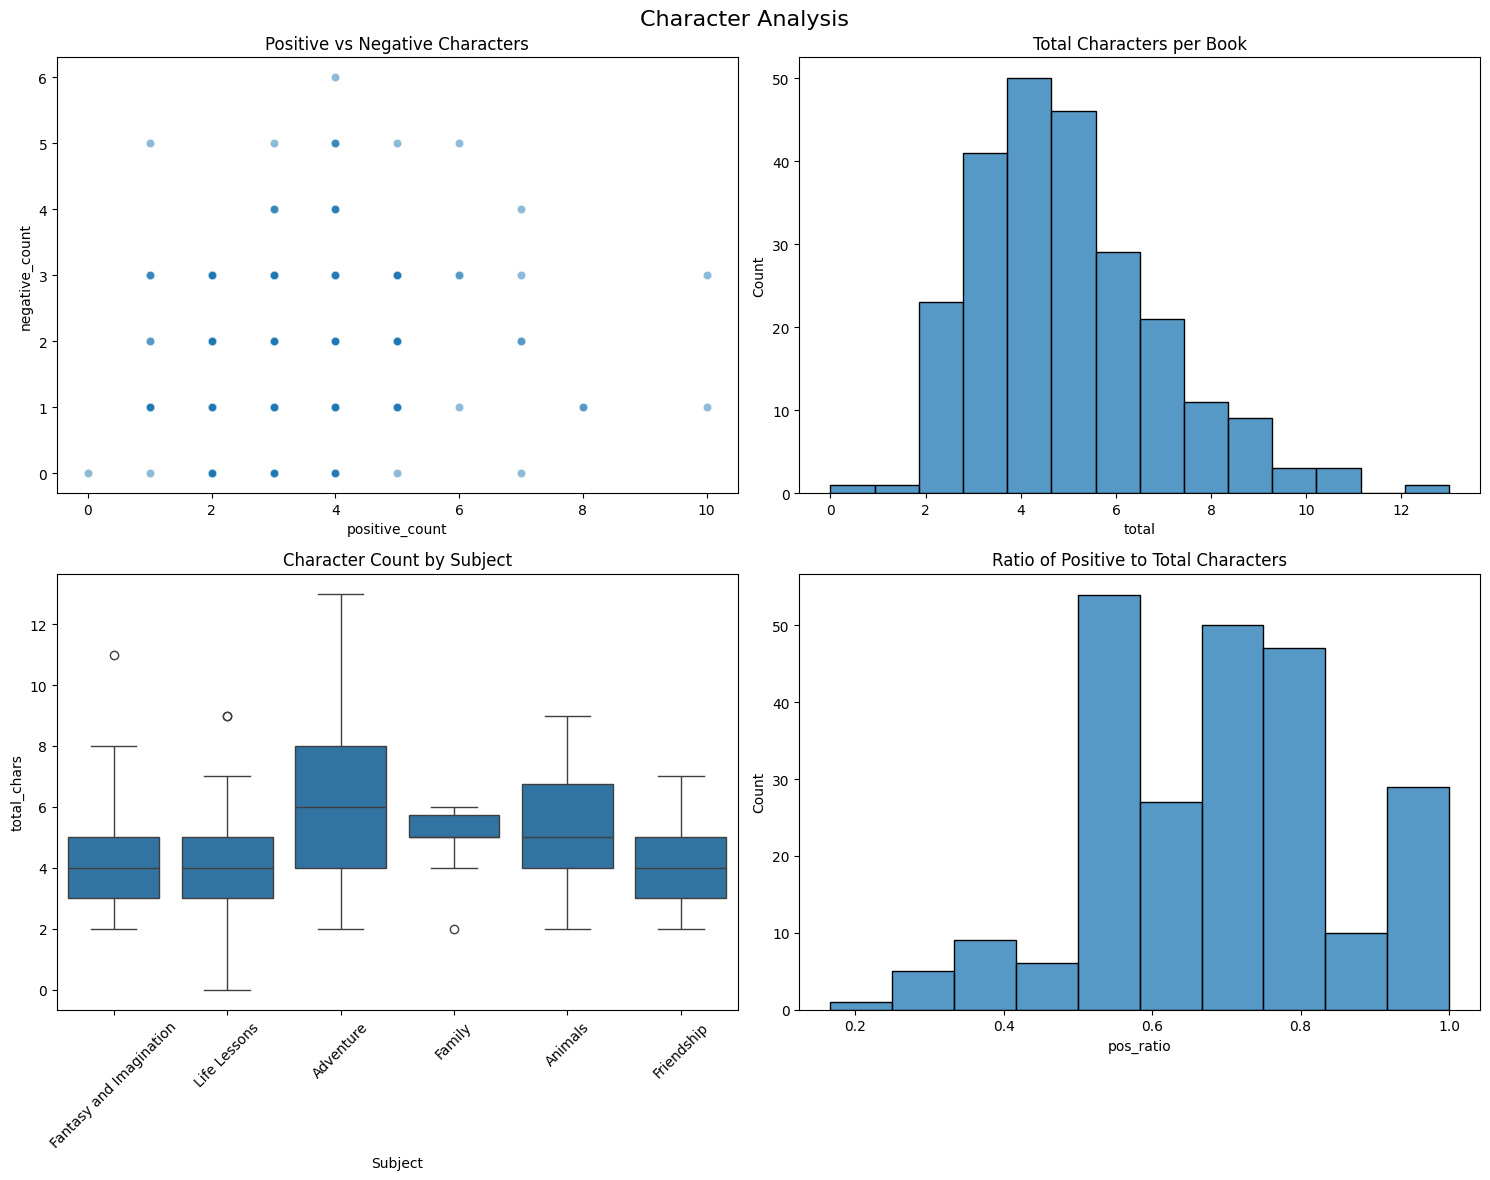

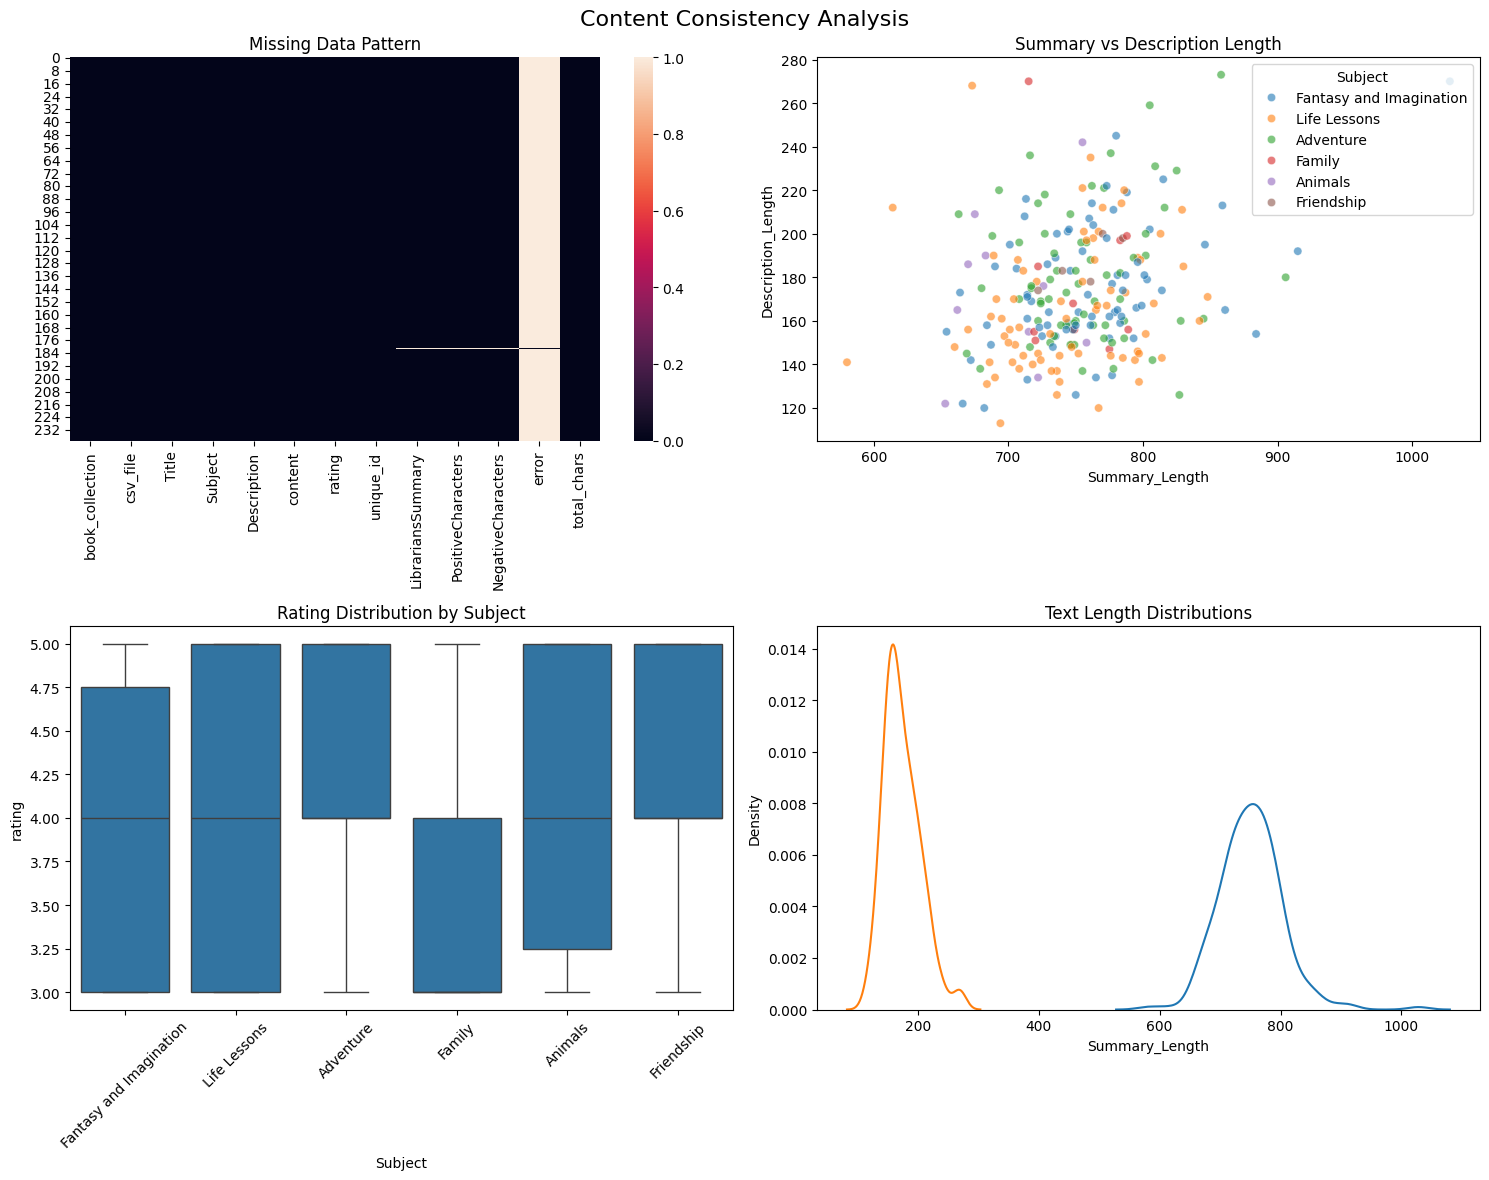

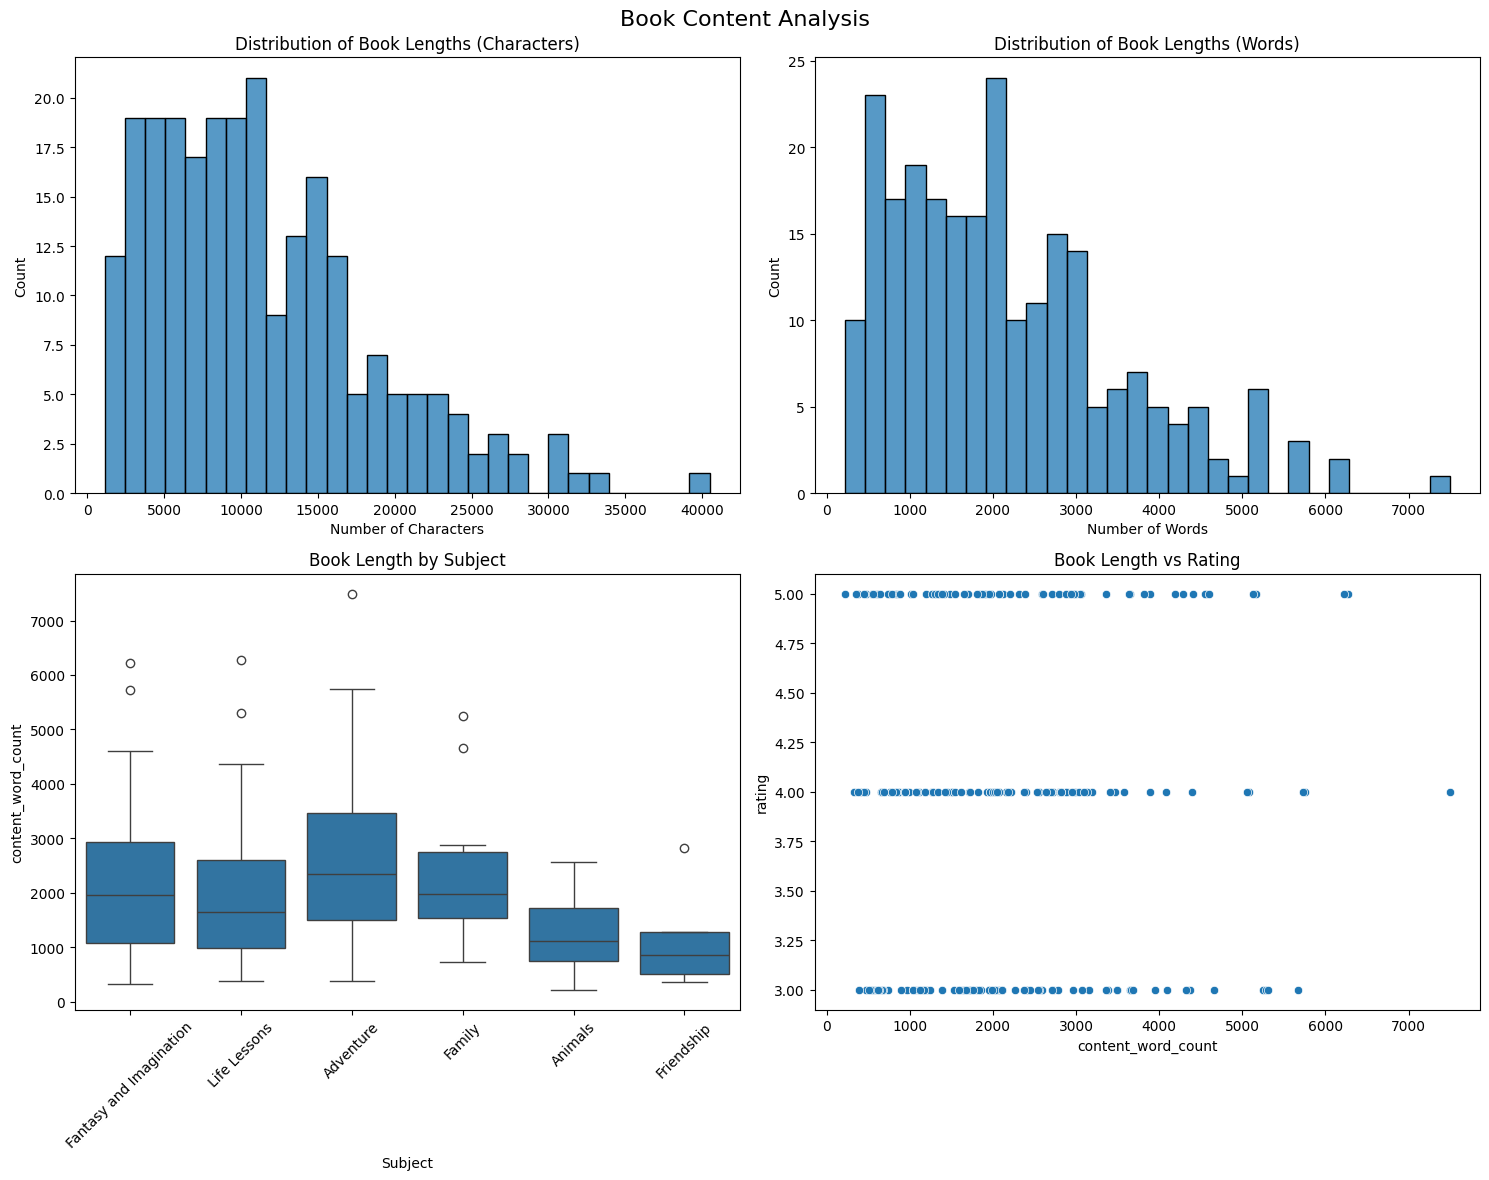

{'text_metrics': {'librarian': word_count                109.046025
  sentence_count              4.041841
  avg_words_per_sentence     27.025832
  unique_word_ratio           0.745743
  dtype: float64,
  'description': word_count                29.125523
  sentence_count             1.769874
  avg_words_per_sentence    18.503835
  unique_word_ratio          0.888228
  dtype: float64},
 'subject_analysis': {'entropy': np.float64(2.0599575512321016),
  'avg_ratings': Subject
  Family                     3.600000
  Fantasy and Imagination    3.851351
  Life Lessons               3.918919
  Animals                    4.100000
  Adventure                  4.136364
  Friendship                 4.200000
  Name: rating, dtype: float64},
 'character_stats': {'avg_positive': np.float64(3.192468619246862),
  'avg_negative': np.float64(1.6861924686192469),
  'books_with_characters': np.float64(99.581589958159),
  'avg_pos_ratio': np.float64(0.6690151934899834),
  'most_common_total': np.int64(4)}

In [53]:
evaluate_ai_columns()

## Cost Analysis For Full Extraction Run (Gpt4o)

In [55]:
# Constants
avg_words = 2160
words_to_tokens_ratio = 1.3
cost_per_million_tokens = 2.50

# Calculations per book
estimated_tokens = avg_words * words_to_tokens_ratio  # ≈ 2,808 tokens
input_cost = (estimated_tokens / 1_000_000) * cost_per_million_tokens

# Output costs
output_tokens = 500  # Assuming average response
output_cost = (output_tokens / 1_000_000) * cost_per_million_tokens

# Total costs
total_cost_per_book = input_cost + output_cost
total_dataset_cost = total_cost_per_book * 239  # Total books

print(f"Per Book Analysis:")
print(f"Estimated input tokens: {estimated_tokens:,.0f}")
print(f"Input cost: ${input_cost:.4f}")
print(f"Output cost (500 tokens): ${output_cost:.4f}")
print(f"Total cost per book: ${total_cost_per_book:.4f}")
print(f"\nTotal Dataset Cost:")
print(f"For {239} books: ${total_dataset_cost:.2f}")

# Cost comparison with different token estimates
token_ratios = [1.2, 1.3, 1.4]
print("\nCost estimates with different word-to-token ratios:")
for ratio in token_ratios:
    est_tokens = avg_words * ratio
    est_cost = ((est_tokens / 1_000_000) * cost_per_million_tokens) * 239
    print(f"Ratio {ratio}: ${est_cost:.2f}")

Per Book Analysis:
Estimated input tokens: 2,808
Input cost: $0.0070
Output cost (500 tokens): $0.0013
Total cost per book: $0.0083

Total Dataset Cost:
For 239 books: $1.98

Cost estimates with different word-to-token ratios:
Ratio 1.2: $1.55
Ratio 1.3: $1.68
Ratio 1.4: $1.81


# Cost Analysis for Chat With Book Feature

In [56]:
# Constants
avg_book_words = 2160
words_to_tokens_ratio = 1.3
cost_per_million_tokens = 2.50

# Average question characteristics
avg_question_words = 20  # Example: "What motivated the main character to help others?"
question_tokens = avg_question_words * words_to_tokens_ratio

# Book tokens (constant across conversation)
book_tokens = avg_book_words * words_to_tokens_ratio

def calculate_chat_cost(num_questions):
    total_tokens = 0
    
    # System prompt + book context (always included)
    total_tokens += book_tokens
    
    # Accumulate conversation tokens
    conversation_history = 0
    for i in range(num_questions):
        # Add question tokens
        total_tokens += question_tokens
        
        # Add previous response to history (assuming 150 word responses)
        if i > 0:
            conversation_history += 150 * words_to_tokens_ratio
            total_tokens += conversation_history
    
    # Calculate cost
    cost = (total_tokens / 1_000_000) * cost_per_million_tokens
    return total_tokens, cost

# Calculate for both scenarios
tokens_2q, cost_2q = calculate_chat_cost(2)
tokens_4q, cost_4q = calculate_chat_cost(4)

print(f"Average book tokens: {book_tokens:,.0f}")
print("\n2-Question Chat:")
print(f"Estimated total tokens: {tokens_2q:,.0f}")
print(f"Estimated cost: ${cost_2q:.4f}")

print("\n4-Question Chat:")
print(f"Estimated total tokens: {tokens_4q:,.0f}")
print(f"Estimated cost: ${cost_4q:.4f}")

print("\nCost per 100 chat sessions:")
print(f"2-Question sessions: ${(cost_2q * 100):.2f}")
print(f"4-Question sessions: ${(cost_4q * 100):.2f}")

Average book tokens: 2,808

2-Question Chat:
Estimated total tokens: 3,055
Estimated cost: $0.0076

4-Question Chat:
Estimated total tokens: 4,082
Estimated cost: $0.0102

Cost per 100 chat sessions:
2-Question sessions: $0.76
4-Question sessions: $1.02
